# Uncertainty Quantification — tổng quan

> **Điểm vào của cả thư mục.** Đọc file này trước để biết ba phương pháp khác nhau chỗ nào,
> rồi mới mở notebook của phương pháp cần xem.

---

## Bài toán

Model giá cho ra **một con số** `p̂`. Nhưng quyết định định giá cần biết con số đó **đáng tin đến
đâu**: dự đoán 100.000đ mà giá thật có thể rơi bất kỳ đâu trong 70.000–130.000đ là chuyện rất
khác so với 95.000–105.000đ.

Uncertainty Quantification biến `p̂` thành **một khoảng** kèm bảo đảm: *"90% số chuyến sẽ có giá
thật nằm trong khoảng này"*.

## Ba phương pháp, ba cơ chế

| | Phương pháp | Dựng khoảng thế nào | Bảo đảm | Notebook |
|---|---|---|---|---|
| 1 | **Conformal chuẩn hoá** | Đo sai số tương đối trên tập calibration, lấy phân vị → `p̂ × (1 ± q)` | ✅ Hữu hạn mẫu, phân phối tự do | `01_conformal_chuan_hoa` |
| 2 | **Quantile Regression** | Train model riêng dự đoán thẳng phân vị 5% và 95% | ❌ Không | `02_quantile_regression` |
| 3 | **CQR** | Lấy khoảng của QR rồi hiệu chỉnh bằng conformal | ✅ Hữu hạn mẫu | `03_CQR` |

**Khác biệt cốt lõi:** phương pháp 1 dùng **một tỷ lệ chung** cho mọi chuyến — đơn giản, khoảng
hẹp, nhưng không thích ứng. Phương pháp 2 và 3 sinh khoảng **riêng cho từng chuyến**.

Đánh đổi đó là chủ đề xuyên suốt cả thư mục.

## Thư mục này có gì

| Notebook | Nội dung | Hình |
|---|---|---|
| `00_TONG_QUAN` | Cơ chế ba phương pháp, trực quan hoá | `VQ1`–`VQ7` |
| `01_conformal_chuan_hoa` | Phương pháp 1 **từ đầu đến cuối** | `UQ1` `UQ2` · `TC*` · `MD*` · `BG*` |
| `02_quantile_regression` | Phương pháp 2 từ đầu đến cuối | `QR1`–`QR4` |
| `03_CQR` | Phương pháp 3 từ đầu đến cuối | `CQ1`–`CQ4` |
| `04_SO_SANH` | 3 phương pháp × 3 mức, chốt khuyến nghị | `UQ3` `UQ4` · `PM*` · `BM*` · `SS*` |
| `05_PHAN_RA_theo_thoi_gian` | Sai số ở thời điểm nhạy cảm | `TT1`–`TT4` |

## Dữ liệu dùng chung

| File | Sinh bởi | Nội dung |
|---|---|---|
| `evaluation/uq_pred_calibration.parquet` | `train/07_sinh_du_lieu_UQ` | 615.908 chuyến để hiệu chỉnh |
| `evaluation/uq_pred_test.parquet` | `train/07_sinh_du_lieu_UQ` | 864.360 chuyến để đánh giá |
| `evaluation/qr_pred_da_muc_*.parquet` | `train/06_train_quantile_da_muc` | 7 phân vị cho QR và CQR |

**Calibration không được dùng để train** — đó là điều kiện để conformal có bảo đảm hữu hạn mẫu.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)

MUC = 0.90        # muc danh muc

cal = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
tes = pd.read_parquet(EVAL / "uq_pred_test.parquet")
qcal = pd.read_parquet(EVAL / "qr_pred_calibration.parquet")
qtes = pd.read_parquet(EVAL / "qr_pred_test.parquet")

print(f"Calibration : {len(cal):,} chuyen   <- DO sai so o day (model chua tung thay)")
print(f"Test        : {len(tes):,} chuyen   <- DANH GIA o day")
print()
print(f"MAE model gia tren test: {np.abs(tes.hybrid_pred - tes.gia_that).mean():,.0f} d")
print(f"MAPE                   : {(np.abs(tes.hybrid_pred-tes.gia_that)/tes.gia_that).mean():.2%}")

Calibration : 615,908 chuyen   <- DO sai so o day (model chua tung thay)
Test        : 864,360 chuyen   <- DANH GIA o day

MAE model gia tren test: 18,048 d
MAPE                   : 14.74%


## 1. Vì sao một con số là không đủ

Nếu model hoàn hảo, mọi điểm sẽ nằm đúng trên đường chéo. Thực tế thì phân tán rộng — và
**chính độ phân tán đó** là thứ UQ phải định lượng.

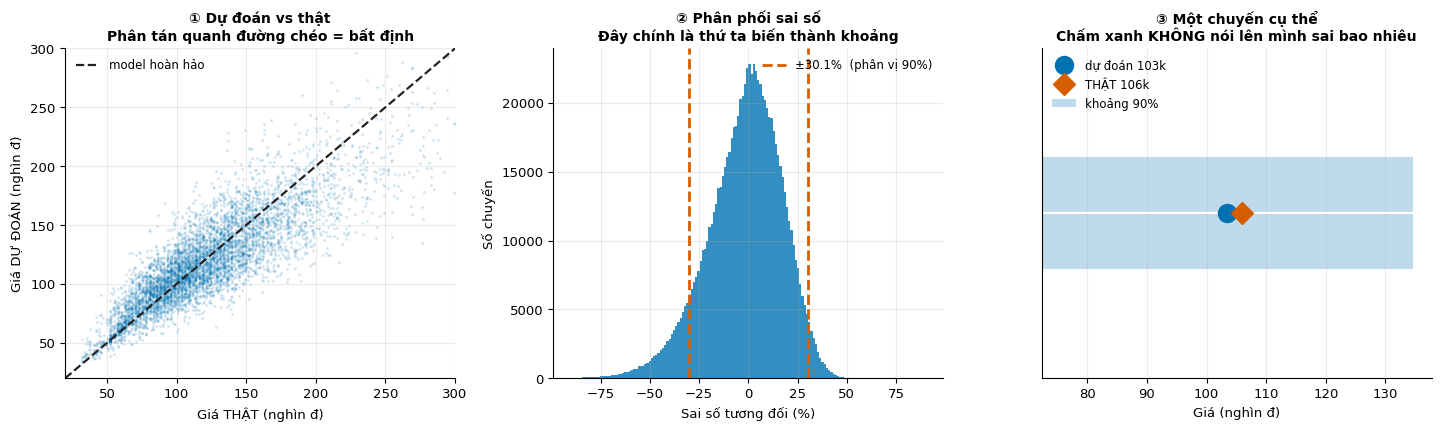

Sai so tuong doi: TB -1.85% | std 18.91%
-> Gan nhu KHONG lech he thong, nhung PHAN TAN rong. UQ dinh luong phan tan nay.


In [2]:
# ═════════ HINH VQ1 — van de ═════════
rng = np.random.default_rng(1)
idx = rng.choice(len(tes), 6000, replace=False)
s = tes.iloc[idx]

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

ax[0].scatter(s.gia_that/1000, s.hybrid_pred/1000, s=4, alpha=.18, color=BLUE, lw=0)
lim = [20, 300]
ax[0].plot(lim, lim, color=INK, lw=1.6, ls="--", label="model hoàn hảo")
ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("Giá THẬT (nghìn đ)"); ax[0].set_ylabel("Giá DỰ ĐOÁN (nghìn đ)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Dự đoán vs thật\nPhân tán quanh đường chéo = bất định",
                fontweight="bold", fontsize=10)

err = (tes.hybrid_pred - tes.gia_that) / tes.hybrid_pred
q_rel = np.quantile((cal.hybrid_pred - cal.gia_that).abs() / cal.hybrid_pred, MUC)
ax[1].hist(err*100, bins=160, range=(-90, 90), color=BLUE, alpha=.8, lw=0)
for v, lb in [(-q_rel*100, None), (q_rel*100, f"±{q_rel:.1%}  (phân vị {MUC:.0%})")]:
    ax[1].axvline(v, color=RED, lw=2, ls="--", label=lb)
ax[1].set_xlabel("Sai số tương đối (%)"); ax[1].set_ylabel("Số chuyến")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Phân phối sai số\nĐây chính là thứ ta biến thành khoảng",
                fontweight="bold", fontsize=10)

i = 3
p_hat, p_that = tes.hybrid_pred.iloc[i], tes.gia_that.iloc[i]
ax[2].axhline(1, color="white")
ax[2].barh([1], [p_hat*2*q_rel/1000], left=[p_hat*(1-q_rel)/1000], height=.34,
           color=BLUE, alpha=.25, label=f"khoảng {MUC:.0%}")
ax[2].plot([p_hat/1000], [1], "o", color=BLUE, ms=13, zorder=5,
           label=f"dự đoán {p_hat/1000:.0f}k")
ax[2].plot([p_that/1000], [1], "D", color=RED, ms=11, zorder=5,
           label=f"THẬT {p_that/1000:.0f}k")
ax[2].set_ylim(0.5, 1.5); ax[2].set_yticks([])
ax[2].set_xlabel("Giá (nghìn đ)")
ax[2].legend(frameon=False, fontsize=8.5, loc="upper left")
ax[2].set_title("③ Một chuyến cụ thể\nChấm xanh KHÔNG nói lên mình sai bao nhiêu",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "VQ1_van_de.png"); plt.show()
print(f"Sai so tuong doi: TB {err.mean():+.2%} | std {err.std():.2%}")
print(f"-> Gan nhu KHONG lech he thong, nhung PHAN TAN rong. UQ dinh luong phan tan nay.")

## 2. Conformal hoạt động thế nào — ba bước

```
① Trên CALIBRATION:  đo sai số tương đối của từng chuyến
② Lấy phân vị 90%:   q = 30,11%
③ Trên TEST:         khoảng = dự_đoán × (1 ± q)
```

Bước ② là toàn bộ "phép màu": nếu 90% chuyến trong calibration có sai số ≤ `q`, thì theo tính
hoán vị được (exchangeability), **90% chuyến tương lai cũng vậy**.

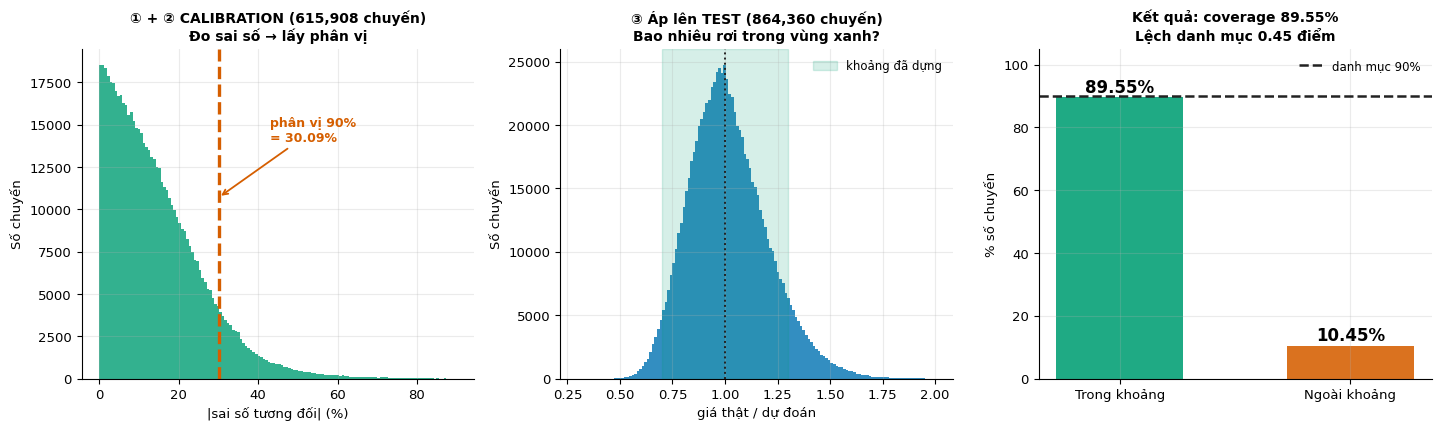

q (phan vi 90% sai so tuong doi) = 0.3009  ->  khoang = du_doan x (1 +/- 30.09%)
Coverage tren test = 89.55%   (danh muc 90%)


In [3]:
# ═════════ HINH VQ2 — co che 3 buoc ═════════
sai_cal = ((cal.hybrid_pred - cal.gia_that).abs() / cal.hybrid_pred).values
q_rel = np.quantile(sai_cal, MUC)

lo = tes.hybrid_pred * (1 - q_rel)
hi = tes.hybrid_pred * (1 + q_rel)
trong = ((tes.gia_that >= lo) & (tes.gia_that <= hi))
cov = trong.mean()

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

ax[0].hist(sai_cal*100, bins=140, range=(0, 90), color=GREEN, alpha=.8, lw=0)
ax[0].axvline(q_rel*100, color=RED, lw=2.4, ls="--")
ax[0].annotate(f"phân vị {MUC:.0%}\n= {q_rel:.2%}", xy=(q_rel*100, ax[0].get_ylim()[1]*.55),
               xytext=(q_rel*100+13, ax[0].get_ylim()[1]*.72), fontsize=9,
               fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.3))
ax[0].set_xlabel("|sai số tương đối| (%)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title(f"① + ② CALIBRATION ({len(cal):,} chuyến)\nĐo sai số → lấy phân vị",
                fontweight="bold", fontsize=10)

ax[1].hist((tes.gia_that/tes.hybrid_pred).values, bins=140, range=(0.3, 2.0),
           color=BLUE, alpha=.8, lw=0)
ax[1].axvspan(1-q_rel, 1+q_rel, color=GREEN, alpha=.16, label="khoảng đã dựng")
ax[1].axvline(1, color=INK, lw=1.4, ls=":")
ax[1].set_xlabel("giá thật / dự đoán"); ax[1].set_ylabel("Số chuyến")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title(f"③ Áp lên TEST ({len(tes):,} chuyến)\nBao nhiêu rơi trong vùng xanh?",
                fontweight="bold", fontsize=10)

b = ax[2].bar(["Trong khoảng", "Ngoài khoảng"], [cov*100, (1-cov)*100],
              color=[GREEN, RED], alpha=.88, width=.55)
for bb, v in zip(b, [cov*100, (1-cov)*100]):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+1.6, f"{v:.2f}%", ha="center",
               fontsize=12, fontweight="bold")
ax[2].axhline(MUC*100, color=INK, lw=1.8, ls="--", label=f"danh mục {MUC:.0%}")
ax[2].set_ylabel("% số chuyến"); ax[2].set_ylim(0, 105)
ax[2].legend(frameon=False, fontsize=8.5)
ax[2].set_title(f"Kết quả: coverage {cov:.2%}\nLệch danh mục {abs(cov-MUC)*100:.2f} điểm",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "VQ2_co_che_conformal.png"); plt.show()
print(f"q (phan vi {MUC:.0%} sai so tuong doi) = {q_rel:.4f}  ->  khoang = du_doan x (1 +/- {q_rel:.2%})")
print(f"Coverage tren test = {cov:.2%}   (danh muc {MUC:.0%})")

## 3. Vì sao phải chuẩn hoá theo giá

Có hai cách dựng khoảng:

| Cách | Khoảng | Vấn đề |
|---|---|---|
| **Độ rộng cố định** | `dự_đoán ± q_abs` (đơn vị đồng) | Chuyến rẻ bị khoảng **quá rộng**, chuyến đắt **quá hẹp** |
| **Chuẩn hoá** | `dự_đoán × (1 ± q_rel)` | Khoảng co giãn theo mức giá |

Hình dưới cho thấy vì sao: sai số **tuyệt đối** tăng mạnh theo mức giá, nhưng sai số **tương đối**
thì gần như phẳng.

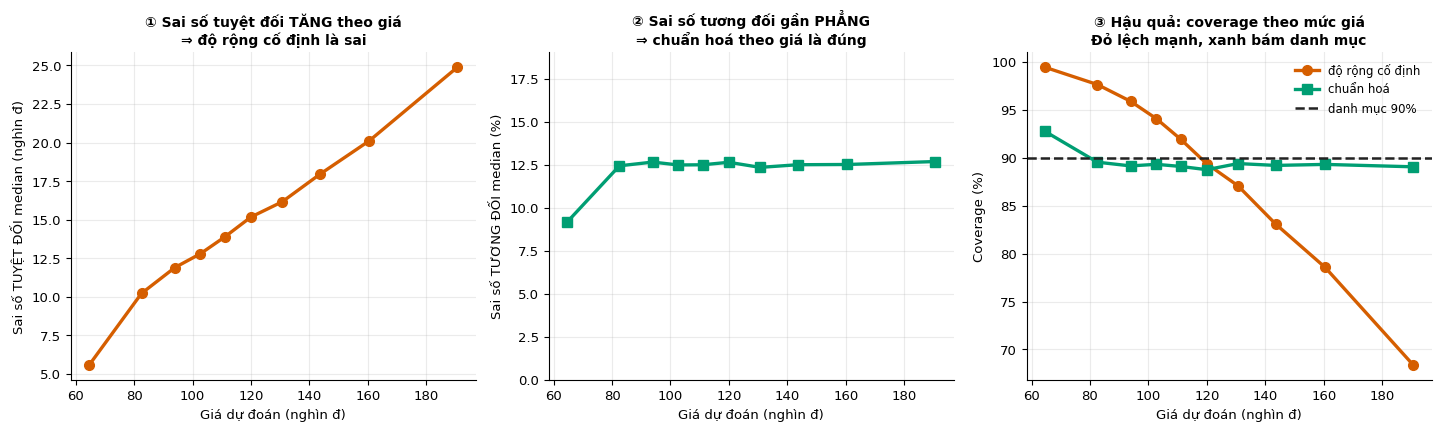

                         lech coverage toi da
Do rong co dinh                        21.60 diem
Chuan hoa                               2.74 diem

-> Day la ly do bien the CHUAN HOA duoc chon lam mac dinh.


In [4]:
# ═════════ HINH VQ3 — vi sao chuan hoa ═════════
q_abs = np.quantile((cal.hybrid_pred - cal.gia_that).abs(), MUC)

t = tes.copy()
t["sai_abs"] = (t.hybrid_pred - t.gia_that).abs()
t["sai_rel"] = t.sai_abs / t.hybrid_pred
t["nhom_gia"] = pd.qcut(t.hybrid_pred, 10, labels=False, duplicates="drop")
t["trong_abs"] = (t.gia_that >= t.hybrid_pred - q_abs) & (t.gia_that <= t.hybrid_pred + q_abs)
t["trong_rel"] = (t.gia_that >= t.hybrid_pred*(1-q_rel)) & (t.gia_that <= t.hybrid_pred*(1+q_rel))

g = t.groupby("nhom_gia").agg(gia=("hybrid_pred", "median"),
                              abs_=("sai_abs", "median"), rel=("sai_rel", "median"),
                              c_abs=("trong_abs", "mean"), c_rel=("trong_rel", "mean"))

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

ax[0].plot(g.gia/1000, g.abs_/1000, marker="o", lw=2.4, color=RED, ms=7)
ax[0].set_xlabel("Giá dự đoán (nghìn đ)"); ax[0].set_ylabel("Sai số TUYỆT ĐỐI median (nghìn đ)")
ax[0].set_title("① Sai số tuyệt đối TĂNG theo giá\n⇒ độ rộng cố định là sai",
                fontweight="bold", fontsize=10)

ax[1].plot(g.gia/1000, g.rel*100, marker="s", lw=2.4, color=GREEN, ms=7)
ax[1].set_ylim(0, max(g.rel*100)*1.5)
ax[1].set_xlabel("Giá dự đoán (nghìn đ)"); ax[1].set_ylabel("Sai số TƯƠNG ĐỐI median (%)")
ax[1].set_title("② Sai số tương đối gần PHẲNG\n⇒ chuẩn hoá theo giá là đúng",
                fontweight="bold", fontsize=10)

ax[2].plot(g.gia/1000, g.c_abs*100, marker="o", lw=2.4, color=RED, ms=7,
           label="độ rộng cố định")
ax[2].plot(g.gia/1000, g.c_rel*100, marker="s", lw=2.4, color=GREEN, ms=7,
           label="chuẩn hoá")
ax[2].axhline(MUC*100, color=INK, lw=1.8, ls="--", label=f"danh mục {MUC:.0%}")
ax[2].set_xlabel("Giá dự đoán (nghìn đ)"); ax[2].set_ylabel("Coverage (%)")
ax[2].legend(frameon=False, fontsize=8.5)
ax[2].set_title("③ Hậu quả: coverage theo mức giá\nĐỏ lệch mạnh, xanh bám danh mục",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "VQ3_vi_sao_chuan_hoa.png"); plt.show()

print(f"{'':22s} {'lech coverage toi da':>22s}")
print(f"{'Do rong co dinh':22s} {abs(g.c_abs*100-MUC*100).max():21.2f} diem")
print(f"{'Chuan hoa':22s} {abs(g.c_rel*100-MUC*100).max():21.2f} diem")
print(f"\n-> Day la ly do bien the CHUAN HOA duoc chon lam mac dinh.")

## 4. Đánh đổi coverage ↔ độ rộng

Muốn chắc chắn hơn thì phải chấp nhận khoảng rộng hơn. Quan hệ này **không tuyến tính** — càng
gần 100% thì độ rộng càng bùng nổ.

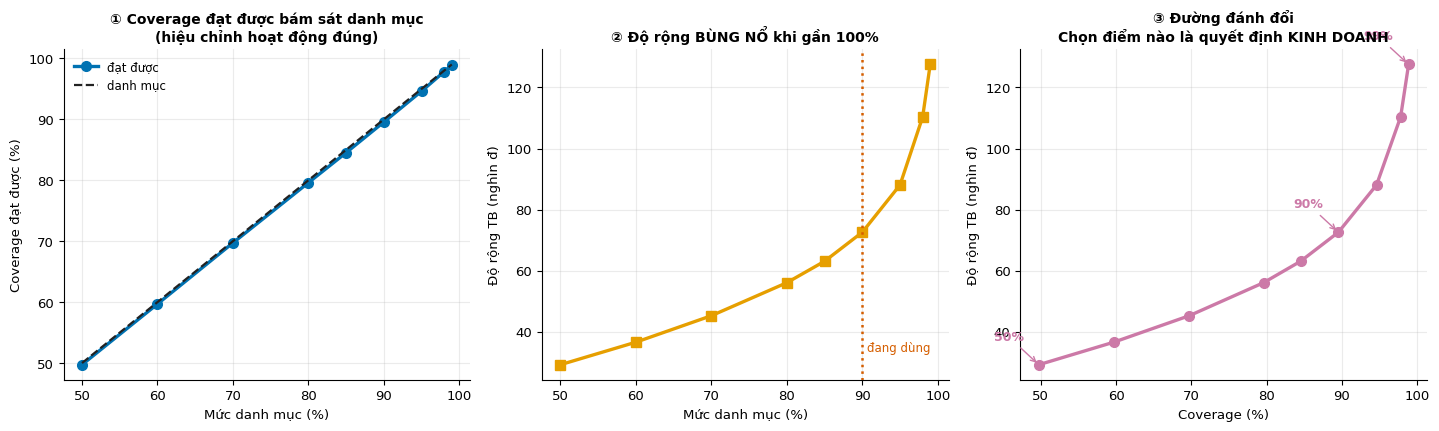

,Danh mục,q (±%),Coverage đạt,Độ rộng TB (đ)
0,50%,12.14%,49.73%,"29,298"
1,60%,15.19%,59.70%,"36,667"
2,70%,18.78%,69.73%,"45,320"
3,80%,23.25%,79.60%,"56,118"
4,85%,26.16%,84.53%,"63,134"
5,90%,30.09%,89.55%,"72,630"
6,95%,36.50%,94.63%,"88,090"
7,98%,45.71%,97.82%,"110,342"
8,99%,52.83%,98.89%,"127,512"


Tu 90% len 99%: do rong tang 76% de doi lay 9.3% coverage.


In [5]:
# ═════════ HINH VQ4 — danh doi ═════════
mucs = np.array([0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.98, 0.99])
qs, covs, rongs = [], [], []
for m in mucs:
    qm = np.quantile(sai_cal, m)
    qs.append(qm)
    lo_m, hi_m = tes.hybrid_pred*(1-qm), tes.hybrid_pred*(1+qm)
    covs.append(((tes.gia_that >= lo_m) & (tes.gia_that <= hi_m)).mean())
    rongs.append((hi_m - lo_m).mean())
covs, rongs, qs = np.array(covs), np.array(rongs), np.array(qs)

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

ax[0].plot(mucs*100, covs*100, marker="o", lw=2.4, color=BLUE, ms=7, label="đạt được")
ax[0].plot(mucs*100, mucs*100, lw=1.6, ls="--", color=INK, label="danh mục")
ax[0].set_xlabel("Mức danh mục (%)"); ax[0].set_ylabel("Coverage đạt được (%)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Coverage đạt được bám sát danh mục\n(hiệu chỉnh hoạt động đúng)",
                fontweight="bold", fontsize=10)

ax[1].plot(mucs*100, np.array(rongs)/1000, marker="s", lw=2.4, color=ORANGE, ms=7)
ax[1].axvline(90, color=RED, lw=1.8, ls=":")
ax[1].text(90.6, np.array(rongs).min()/1000*1.15, "đang dùng", fontsize=8.5, color=RED)
ax[1].set_xlabel("Mức danh mục (%)"); ax[1].set_ylabel("Độ rộng TB (nghìn đ)")
ax[1].set_title("② Độ rộng BÙNG NỔ khi gần 100%", fontweight="bold", fontsize=10)

ax[2].plot(covs*100, np.array(rongs)/1000, marker="o", lw=2.4, color=PURPLE, ms=7)
for m, c, r in zip(mucs, covs, rongs):
    if m in (0.50, 0.90, 0.99):
        ax[2].annotate(f"{m:.0%}", xy=(c*100, r/1000), xytext=(c*100-6, r/1000+8),
                       fontsize=9, fontweight="bold", color=PURPLE,
                       arrowprops=dict(arrowstyle="->", color=PURPLE, lw=1))
ax[2].set_xlabel("Coverage (%)"); ax[2].set_ylabel("Độ rộng TB (nghìn đ)")
ax[2].set_title("③ Đường đánh đổi\nChọn điểm nào là quyết định KINH DOANH",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "VQ4_danh_doi.png"); plt.show()

bang = pd.DataFrame({"Danh mục": [f"{m:.0%}" for m in mucs],
                     "q (±%)": [f"{q:.2%}" for q in qs],
                     "Coverage đạt": [f"{c:.2%}" for c in covs],
                     "Độ rộng TB (đ)": [f"{r:,.0f}" for r in rongs]})
display(bang)
print(f"Tu 90% len 99%: do rong tang {rongs[-1]/rongs[5]-1:.0%} de doi lay {covs[-1]-covs[5]:.1%} coverage.")

## 5. Coverage **điều kiện** — tiêu chí phân biệt thật sự

Coverage tổng 90% **không có nghĩa** mọi nhóm đều được 90%. Model có thể "bù trừ":
95% ở giờ dễ, 85% ở giờ khó — trung bình vẫn đẹp, nhưng **khách đi giờ cao điểm bị phục vụ tệ
hơn một cách có hệ thống**.

Đây là chỗ **CQR thắng**, và là lý do thật sự để chọn phương pháp.

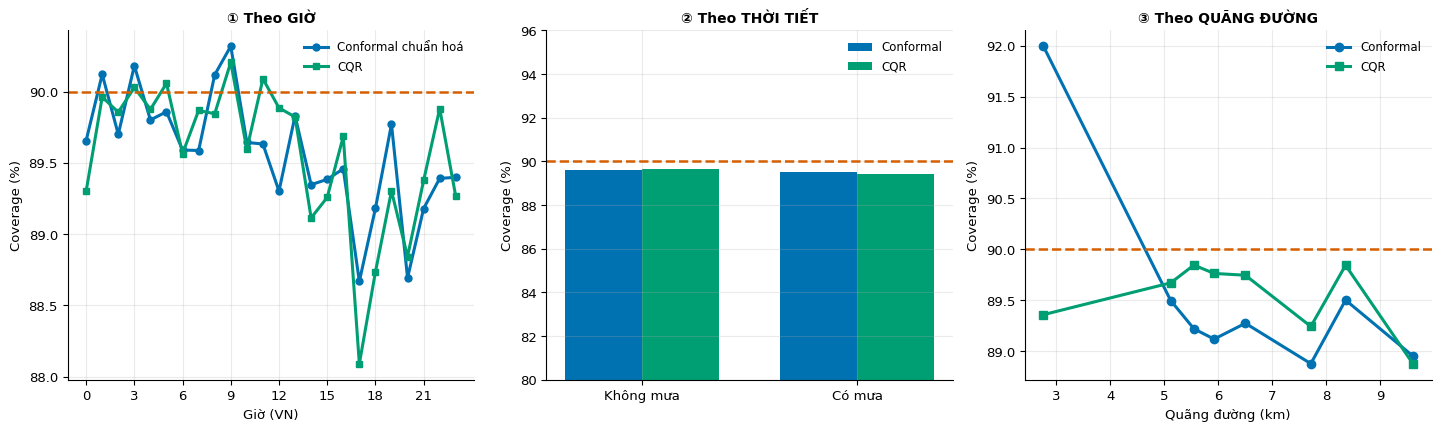

Chieu                         Conformal            CQR
--------------------------------------------------------
Gio                             1.33 diem        1.91 diem
Quang duong                     2.00 diem        1.13 diem
Thoi tiet                       0.50 diem        0.58 diem

(lech coverage toi da so voi danh muc — cang nho cang cong bang giua cac nhom)

SO SANH DAY DU — lech coverage toi da so voi danh muc (diem %)


,Phương pháp,Giờ,Quãng đường,Thời tiết,XẤU NHẤT
0,Conformal chuan hoa,1.33,2.00,0.50,2.00
1,Quantile Regression tho,2.36,1.93,1.03,2.36
2,CQR,1.91,1.13,0.58,1.91


KHONG co phuong phap nao THANG TUYET DOI:
    Giờ            -> tot nhat: Conformal chuan hoa
    Quãng đường    -> tot nhat: CQR
    Thời tiết      -> tot nhat: Conformal chuan hoa
    XẤU NHẤT       -> tot nhat: CQR


In [6]:
# ═════════ HINH VQ5 — coverage dieu kien ═════════
E = np.maximum(qcal.q05 - qcal.gia_that, qcal.gia_that - qcal.q95).values
k = min(int(np.ceil((len(qcal) + 1) * MUC)), len(qcal))
q_cqr = np.sort(E)[k - 1]

v = qtes.copy()
v["trong_cqr"] = (v.gia_that >= v.q05 - q_cqr) & (v.gia_that <= v.q95 + q_cqr)
v["trong_conf"] = ((tes.gia_that.values >= (tes.hybrid_pred*(1-q_rel)).values) &
                   (tes.gia_that.values <= (tes.hybrid_pred*(1+q_rel)).values))
v["nhom_km"] = pd.qcut(v.quang_duong, 8, labels=False, duplicates="drop")
v["mua"] = v.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"])

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

for col, ten, mk in [("trong_conf", "Conformal chuẩn hoá", "o"), ("trong_cqr", "CQR", "s")]:
    gg = v.groupby("gio_vn")[col].mean()*100
    ax[0].plot(gg.index, gg.values, marker=mk, lw=2.2, ms=5,
               color=BLUE if col == "trong_conf" else GREEN, label=ten)
ax[0].axhline(MUC*100, color=RED, lw=1.8, ls="--")
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("Coverage (%)")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Theo GIỜ", fontweight="bold", fontsize=10)

x = np.arange(2); w = .36
c1 = [v[~v.mua].trong_conf.mean()*100, v[v.mua].trong_conf.mean()*100]
c2 = [v[~v.mua].trong_cqr.mean()*100, v[v.mua].trong_cqr.mean()*100]
ax[1].bar(x-w/2, c1, w, color=BLUE, label="Conformal")
ax[1].bar(x+w/2, c2, w, color=GREEN, label="CQR")
ax[1].axhline(MUC*100, color=RED, lw=1.8, ls="--")
ax[1].set_xticks(x); ax[1].set_xticklabels(["Không mưa", "Có mưa"])
ax[1].set_ylabel("Coverage (%)"); ax[1].set_ylim(80, 96)
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Theo THỜI TIẾT", fontweight="bold", fontsize=10)

for col, ten, mk in [("trong_conf", "Conformal", "o"), ("trong_cqr", "CQR", "s")]:
    gg = v.groupby("nhom_km")[col].mean()*100
    km = v.groupby("nhom_km").quang_duong.median()
    ax[2].plot(km.values, gg.values, marker=mk, lw=2.2, ms=6,
               color=BLUE if col == "trong_conf" else GREEN, label=ten)
ax[2].axhline(MUC*100, color=RED, lw=1.8, ls="--")
ax[2].set_xlabel("Quãng đường (km)"); ax[2].set_ylabel("Coverage (%)")
ax[2].legend(frameon=False, fontsize=8.5)
ax[2].set_title("③ Theo QUÃNG ĐƯỜNG", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "VQ5_coverage_dieu_kien.png"); plt.show()

print(f"{'Chieu':<16} {'Conformal':>22s} {'CQR':>14s}")
print("-" * 56)
for ten, khoa in [("Gio", "gio_vn"), ("Quang duong", "nhom_km")]:
    a = abs(v.groupby(khoa).trong_conf.mean()*100 - MUC*100).max()
    b = abs(v.groupby(khoa).trong_cqr.mean()*100 - MUC*100).max()
    print(f"{ten:<16} {a:19.2f} diem {b:11.2f} diem")
a = abs(np.array(c1) - MUC*100).max(); b = abs(np.array(c2) - MUC*100).max()
print(f"{'Thoi tiet':<16} {a:19.2f} diem {b:11.2f} diem")
print("\n(lech coverage toi da so voi danh muc — cang nho cang cong bang giua cac nhom)")

# ── So sanh DAY DU ca 3 phuong phap ──
v["trong_qr"] = (v.gia_that >= v.q05) & (v.gia_that <= v.q95)
print()
print("=" * 70)
print("SO SANH DAY DU — lech coverage toi da so voi danh muc (diem %)")
print("=" * 70)
rows_dk = []
for ten_pp, col in [("Conformal chuan hoa", "trong_conf"),
                    ("Quantile Regression tho", "trong_qr"),
                    ("CQR", "trong_cqr")]:
    lg = abs(v.groupby("gio_vn")[col].mean()*100 - MUC*100).max()
    lk = abs(v.groupby("nhom_km")[col].mean()*100 - MUC*100).max()
    lt = abs(v.groupby("mua")[col].mean()*100 - MUC*100).max()
    rows_dk.append({"Phương pháp": ten_pp, "Giờ": round(lg, 2),
                    "Quãng đường": round(lk, 2), "Thời tiết": round(lt, 2),
                    "XẤU NHẤT": round(max(lg, lk, lt), 2)})
bdk = pd.DataFrame(rows_dk)
display(bdk)

print("KHONG co phuong phap nao THANG TUYET DOI:")
for c in ["Giờ", "Quãng đường", "Thời tiết", "XẤU NHẤT"]:
    print(f"    {c:14s} -> tot nhat: {bdk.loc[bdk[c].idxmin(), 'Phương pháp']}")

## 6. CQR hiệu chỉnh Quantile Regression thế nào

Quantile Regression train trực tiếp ra `q05`, `q50`, `q95` — nhưng **không có bảo đảm** coverage.
CQR nới rộng khoảng đó **vừa đủ** bằng conformal.

```python
E = max(q05 − y_thật,  y_thật − q95)     # dương nếu rơi NGOÀI khoảng
k = ceil((n + 1) × 0,90)                  # hiệu chỉnh hữu hạn mẫu
q_cqr = sorted(E)[k − 1]
khoảng = [q05 − q_cqr,  q95 + q_cqr]
```

`E` đo *"khoảng của QR hụt bao nhiêu"*. Giá trị **âm** nghĩa là khoảng đã thừa.

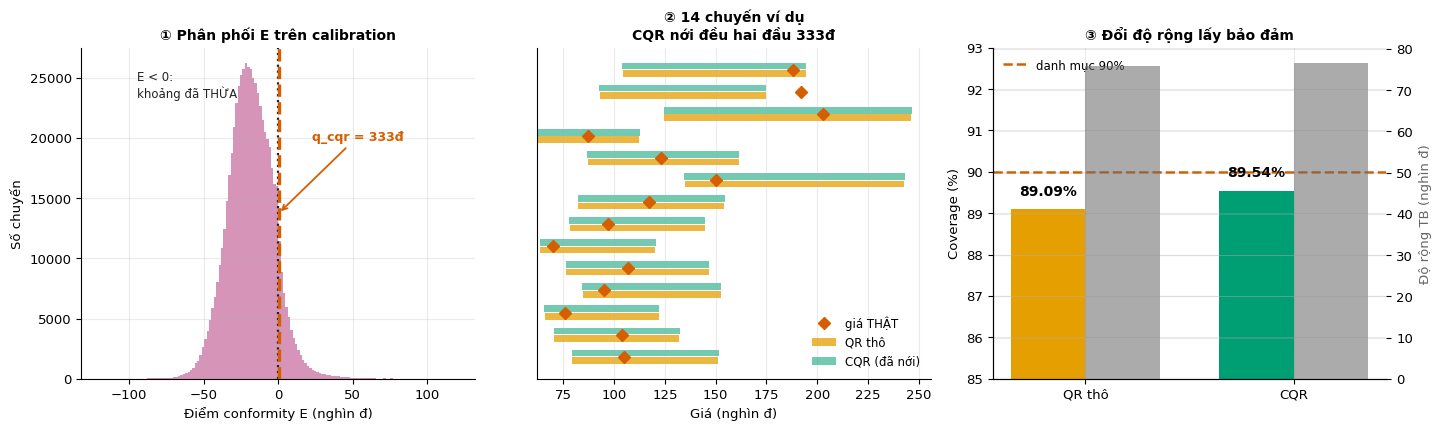

k = ceil((615,908 + 1) x 0.9) = 554,319   ->  q_cqr = E thu 554,319 = 333 d
QR tho : coverage 89.09% | do rong 75,783 d  (KHONG bao dam)
CQR    : coverage 89.54% | do rong 76,449 d  (CO bao dam huu han mau)
-> Tra gia +0.9% do rong de doi lay bao dam thong ke.


In [7]:
# ═════════ HINH VQ6 — co che CQR ═════════
cov_qr = ((qtes.gia_that >= qtes.q05) & (qtes.gia_that <= qtes.q95)).mean()
cov_cq = v.trong_cqr.mean()
rong_qr = (qtes.q95 - qtes.q05).mean()
rong_cq = (qtes.q95 + q_cqr - qtes.q05 + q_cqr).mean()

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

ax[0].hist(E/1000, bins=150, range=(-120, 120), color=PURPLE, alpha=.8, lw=0)
ax[0].axvline(0, color=INK, lw=1.6, ls=":")
ax[0].axvline(q_cqr/1000, color=RED, lw=2.4, ls="--")
ax[0].annotate(f"q_cqr = {q_cqr:,.0f}đ", xy=(q_cqr/1000, ax[0].get_ylim()[1]*.5),
               xytext=(q_cqr/1000+22, ax[0].get_ylim()[1]*.72), fontsize=9,
               fontweight="bold", color=RED,
               arrowprops=dict(arrowstyle="->", color=RED, lw=1.3))
ax[0].text(-95, ax[0].get_ylim()[1]*.85, "E < 0:\nkhoảng đã THỪA", fontsize=8.5, color=INK)
ax[0].set_xlabel("Điểm conformity E (nghìn đ)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title("① Phân phối E trên calibration", fontweight="bold", fontsize=10)

n = 14
ss = qtes.iloc[rng.choice(len(qtes), n, replace=False)].reset_index(drop=True)
yy = np.arange(n)
ax[1].barh(yy-0.17, (ss.q95-ss.q05)/1000, left=ss.q05/1000, height=.3,
           color=ORANGE, alpha=.75, label="QR thô")
ax[1].barh(yy+0.17, (ss.q95+q_cqr-ss.q05+q_cqr)/1000, left=(ss.q05-q_cqr)/1000,
           height=.3, color=GREEN, alpha=.55, label="CQR (đã nới)")
ax[1].plot(ss.gia_that/1000, yy, "D", color=RED, ms=6, zorder=5, label="giá THẬT")
ax[1].set_yticks([]); ax[1].set_xlabel("Giá (nghìn đ)")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title(f"② {n} chuyến ví dụ\nCQR nới đều hai đầu {q_cqr:,.0f}đ",
                fontweight="bold", fontsize=10)

x = np.arange(2); w = .36
b1 = ax[2].bar(x-w/2, [cov_qr*100, cov_cq*100], w, color=[ORANGE, GREEN])
ax[2].axhline(MUC*100, color=RED, lw=1.8, ls="--", label=f"danh mục {MUC:.0%}")
for bb, val in zip(b1, [cov_qr*100, cov_cq*100]):
    ax[2].text(bb.get_x()+bb.get_width()/2, val+.35, f"{val:.2f}%", ha="center",
               fontsize=10, fontweight="bold")
ax2 = ax[2].twinx()
ax2.bar(x+w/2, [rong_qr/1000, rong_cq/1000], w, color=MUT, alpha=.55)
ax2.set_ylabel("Độ rộng TB (nghìn đ)", color=MUT)
ax[2].set_xticks(x); ax[2].set_xticklabels(["QR thô", "CQR"])
ax[2].set_ylabel("Coverage (%)"); ax[2].set_ylim(85, 93)
ax[2].legend(frameon=False, fontsize=8.5, loc="upper left")
ax[2].set_title("③ Đổi độ rộng lấy bảo đảm", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "VQ6_co_che_CQR.png"); plt.show()

print(f"k = ceil(({len(qcal):,} + 1) x {MUC}) = {k:,}   ->  q_cqr = E thu {k:,} = {q_cqr:,.0f} d")
print(f"QR tho : coverage {cov_qr:.2%} | do rong {rong_qr:,.0f} d  (KHONG bao dam)")
print(f"CQR    : coverage {cov_cq:.2%} | do rong {rong_cq:,.0f} d  (CO bao dam huu han mau)")
print(f"-> Tra gia {rong_cq/rong_qr-1:+.1%} do rong de doi lay bao dam thong ke.")

## 7. Độ rộng thích ứng — model biết chỗ nào nó kém chắc chắn

Điểm mạnh của QR/CQR so với conformal chuẩn hoá: độ rộng **không tỷ lệ cứng** với giá dự đoán mà
thay đổi theo **độ khó của từng bối cảnh**.

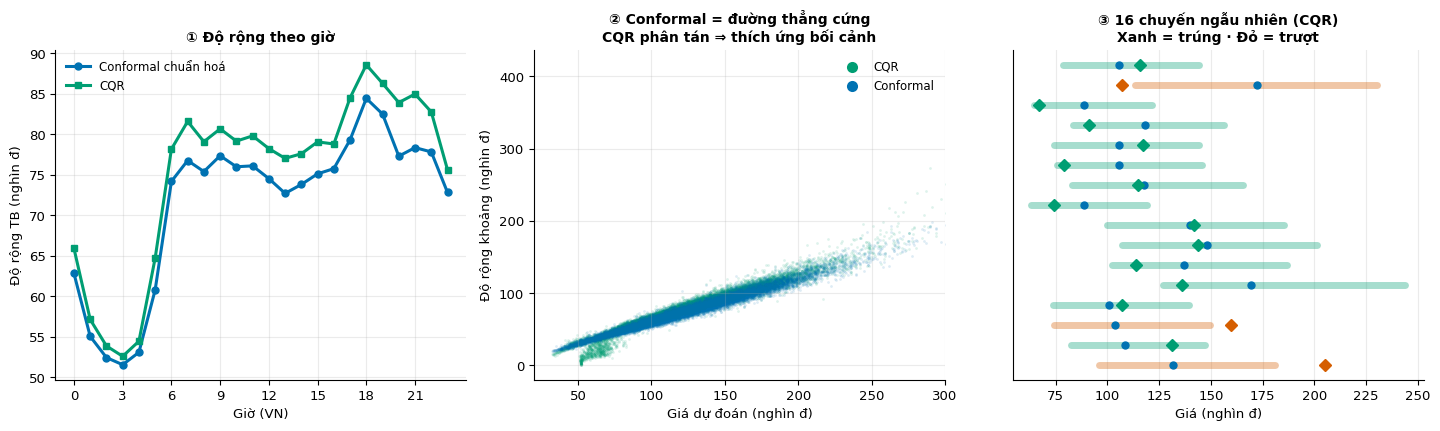

BIEN DO do rong theo gio (max/min - 1):
  Conformal chuan hoa :  63.7%
  CQR                 :  68.4%

-> CQR bien thien nhieu hon = phan ung manh hon voi do kho cua boi canh.


In [8]:
# ═════════ HINH VQ7 — do rong thich ung ═════════
v["rong_cqr"] = (v.q95 + q_cqr) - (v.q05 - q_cqr)
v["rong_conf"] = (tes.hybrid_pred.values * 2 * q_rel)

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

g1 = v.groupby("gio_vn")[["rong_cqr", "rong_conf"]].mean()/1000
ax[0].plot(g1.index, g1.rong_conf, marker="o", lw=2.2, ms=5, color=BLUE,
           label="Conformal chuẩn hoá")
ax[0].plot(g1.index, g1.rong_cqr, marker="s", lw=2.2, ms=5, color=GREEN, label="CQR")
ax[0].set_xlabel("Giờ (VN)"); ax[0].set_ylabel("Độ rộng TB (nghìn đ)")
ax[0].set_xticks(range(0, 24, 3)); ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Độ rộng theo giờ", fontweight="bold", fontsize=10)

ax[1].scatter(v.q50.iloc[::40]/1000, v.rong_cqr.iloc[::40]/1000, s=4, alpha=.13,
              color=GREEN, lw=0, label="CQR")
ax[1].scatter(v.q50.iloc[::40]/1000, v.rong_conf.iloc[::40]/1000, s=4, alpha=.13,
              color=BLUE, lw=0, label="Conformal")
ax[1].set_xlim(20, 300)
ax[1].set_xlabel("Giá dự đoán (nghìn đ)"); ax[1].set_ylabel("Độ rộng khoảng (nghìn đ)")
leg = ax[1].legend(frameon=False, fontsize=8.5, markerscale=4)
for lh in leg.legend_handles:
    lh.set_alpha(1)
ax[1].set_title("② Conformal = đường thẳng cứng\nCQR phân tán ⇒ thích ứng bối cảnh",
                fontweight="bold", fontsize=10)

n = 16
ss = v.iloc[rng.choice(len(v), n, replace=False)].reset_index(drop=True)
yy = np.arange(n)
mau = [GREEN if (r.gia_that >= r.q05-q_cqr and r.gia_that <= r.q95+q_cqr) else RED
       for _, r in ss.iterrows()]
for i2, r in ss.iterrows():
    ax[2].plot([(r.q05-q_cqr)/1000, (r.q95+q_cqr)/1000], [i2, i2],
               lw=5, color=mau[i2], alpha=.35, solid_capstyle="round")
    ax[2].plot(r.q50/1000, i2, "o", color=BLUE, ms=5, zorder=4)
    ax[2].plot(r.gia_that/1000, i2, "D", color=mau[i2], ms=6, zorder=5)
ax[2].set_yticks([]); ax[2].set_xlabel("Giá (nghìn đ)")
ax[2].set_title(f"③ {n} chuyến ngẫu nhiên (CQR)\nXanh = trúng · Đỏ = trượt",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "VQ7_do_rong_thich_ung.png"); plt.show()

print("BIEN DO do rong theo gio (max/min - 1):")
print(f"  Conformal chuan hoa : {(g1.rong_conf.max()/g1.rong_conf.min()-1)*100:5.1f}%")
print(f"  CQR                 : {(g1.rong_cqr.max()/g1.rong_cqr.min()-1)*100:5.1f}%")
print("\n-> CQR bien thien nhieu hon = phan ung manh hon voi do kho cua boi canh.")